# Synthetic Fraud Data Discovery

Generating and exploring a synthetic fraud transaction dataset.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch_geometric.data import Data
from torch_geometric.utils import degree
import warnings
warnings.filterwarnings("ignore")


##  Generate Synthetic Fraud Graph


In [4]:
def generate_synthetic_fraud_graph(num_accounts=5000, fraud_ratio=0.1, avg_degree=8, seed=42):
    """
    Generate a synthetic fraud transaction graph.
    
    The graph simulates realistic fraud patterns:
    - Low homophily (fraudsters transact with legitimate accounts)
    - Repetitive transaction patterns (motifs)
    - Feature overlap between classes
    """
    rng = np.random.default_rng(seed)
    
    # Assign risk profiles to accounts (latent variable)
    # Profile 0: low risk, Profile 1: medium risk, Profile 2: high risk
    profiles = rng.choice(3, size=num_accounts, p=[0.6, 0.25, 0.15])
    
    # Initial fraud labels based on risk profile
    fraud_probs = np.array([0.03, 0.15, 0.45])
    y = rng.binomial(1, fraud_probs[profiles]).astype(np.int64)
    
    # Adjust to target fraud ratio
    current_ratio = y.mean()
    if current_ratio > 0:
        scale = fraud_ratio / current_ratio
        keep_mask = rng.random(num_accounts) < scale
        y = np.where(y == 1, keep_mask.astype(np.int64), 0)
    
    # Generate edges (transactions)
    num_edges = num_accounts * avg_degree
    src_list, dst_list = [], []
    amounts, times, channels = [], [], []
    
    for _ in range(num_edges):
        src = rng.integers(0, num_accounts)
        
        # Low homophily: fraud accounts often transact with legitimate ones
        if rng.random() < 0.7:  # 70% heterophilous edges
            candidates = np.where(y != y[src])[0]
        else:
            candidates = np.where(y == y[src])[0]
        
        if len(candidates) == 0:
            candidates = np.arange(num_accounts)
        
        dst = rng.choice(candidates)
        
        src_list.append(src)
        dst_list.append(dst)
        
        # Transaction amount (log-normal, slightly higher for fraud)
        base_mu = 4.0 + 0.3 * (y[src] or y[dst])
        amt = np.exp(rng.normal(base_mu, 0.8))
        amounts.append(amt)
        
        # Time of day (0-23), fraud slightly more at night
        if (y[src] or y[dst]) and rng.random() < 0.3:
            t = rng.choice([0, 1, 2, 3, 22, 23])
        else:
            t = rng.integers(0, 24)
        times.append(t)
        
        # Channel (0, 1, 2)
        channels.append(rng.integers(0, 3))
    
    # Add repetitive motifs (triangular patterns)
    n_motifs = 300
    for _ in range(n_motifs):
        a, b, c = rng.choice(num_accounts, 3, replace=False)
        for s, d in [(a, b), (b, c), (c, a)]:
            src_list.append(s)
            dst_list.append(d)
            amounts.append(np.exp(rng.normal(4.5, 0.5)))
            times.append(rng.integers(0, 24))
            channels.append(rng.integers(0, 3))
    
    # Build tensors
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    
    # Edge features
    edge_attr = torch.tensor(np.column_stack([
        np.log1p(amounts),
        np.array(times) / 23.0,
        np.eye(3)[channels]
    ]), dtype=torch.float32)
    
    # Node features (aggregated from edges)
    src_t = torch.tensor(src_list, dtype=torch.long)
    dst_t = torch.tensor(dst_list, dtype=torch.long)
    amt_t = torch.tensor(amounts, dtype=torch.float32)
    time_t = torch.tensor(times, dtype=torch.float32)
    
    in_deg = degree(dst_t, num_nodes=num_accounts).unsqueeze(-1)
    out_deg = degree(src_t, num_nodes=num_accounts).unsqueeze(-1)
    
    total_in = torch.zeros(num_accounts)
    total_out = torch.zeros(num_accounts)
    total_in.index_add_(0, dst_t, amt_t)
    total_out.index_add_(0, src_t, amt_t)
    
    avg_in = (total_in / (in_deg.squeeze() + 1e-6)).unsqueeze(-1)
    avg_out = (total_out / (out_deg.squeeze() + 1e-6)).unsqueeze(-1)
    
    # Night transaction ratio
    night_mask = ((time_t < 6) | (time_t >= 22)).float()
    night_in = torch.zeros(num_accounts)
    night_out = torch.zeros(num_accounts)
    night_in.index_add_(0, dst_t, night_mask)
    night_out.index_add_(0, src_t, night_mask)
    night_in_ratio = (night_in / (in_deg.squeeze() + 1e-6)).unsqueeze(-1)
    night_out_ratio = (night_out / (out_deg.squeeze() + 1e-6)).unsqueeze(-1)
    
    # Add noise features
    noise = torch.randn(num_accounts, 4)
    
    x = torch.cat([
        in_deg, out_deg,
        total_in.unsqueeze(-1), total_out.unsqueeze(-1),
        avg_in, avg_out,
        night_in_ratio, night_out_ratio,
        noise
    ], dim=-1)
    
    y_tensor = torch.tensor(y, dtype=torch.long)
    
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_tensor)
    
    return data

In [5]:
data = generate_synthetic_fraud_graph(num_accounts=5000, fraud_ratio=0.1, seed=42)

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Node features: {data.x.shape[1]}")
print(f"Edge features: {data.edge_attr.shape[1]}")

Nodes: 5000
Edges: 40900
Node features: 12
Edge features: 5


##  Class Distribution

In [6]:
labels = data.y.numpy()
unique, counts = np.unique(labels, return_counts=True)

for lbl, cnt in zip(unique, counts):
    name = 'Fraud' if lbl == 1 else 'Legitimate'
    print(f"{name}: {cnt} ({cnt/len(labels)*100:.2f}%)")

Legitimate: 4507 (90.14%)
Fraud: 493 (9.86%)


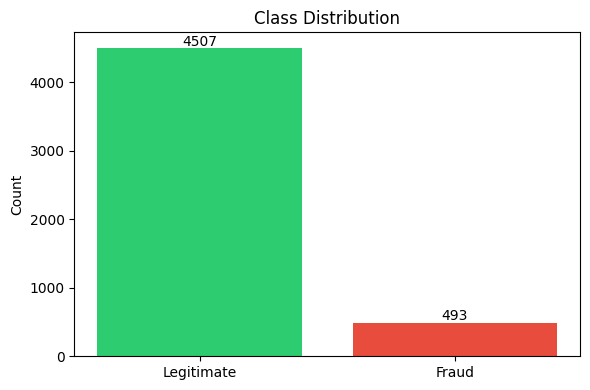

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Legitimate', 'Fraud'], counts, color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            str(cnt), ha='center')
plt.tight_layout()
plt.show()

Approximately 10% fraud rate. This imbalance is intentional and realistic for fraud detection scenarios.

##  Node Feature Analysis

In [8]:
feature_names = ['in_deg', 'out_deg', 'total_in', 'total_out', 
                 'avg_in', 'avg_out', 'night_in_ratio', 'night_out_ratio',
                 'noise_1', 'noise_2', 'noise_3', 'noise_4']

df = pd.DataFrame(data.x.numpy(), columns=feature_names)
df['label'] = labels
df.describe()

,in_deg,out_deg,total_in,total_out,avg_in,avg_out,night_in_ratio,night_out_ratio,noise_1,noise_2,noise_3,noise_4,label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.180000,8.180000,779.705444,779.705383,81.876022,95.330185,0.369891,0.474148,0.009558,0.011643,0.006354,0.001443,0.098600
std,15.288778,2.827154,1605.185181,377.308777,52.217422,35.979256,0.302121,0.190403,0.996260,1.001053,0.998803,0.993226,0.298154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.344621,-3.536745,-4.841489,-3.470538,0.000000
25%,2.000000,6.000000,128.570572,513.190903,51.454503,72.350780,0.000000,0.333333,-0.658832,-0.656819,-0.656866,-0.684474,0.000000
50%,3.000000,8.000000,249.399033,723.248260,75.901798,89.657917,0.333333,0.500000,0.011925,0.025459,0.006307,0.004727,0.000000
75%,5.000000,10.000000,437.139404,999.609222,102.553329,111.584398,0.525647,0.600000,0.692223,0.688361,0.676377,0.672144,0.000000
max,76.000000,20.000000,10098.440430,4593.734375,927.892456,638.613892,1.000000,1.000000,3.970522,3.527218,3.672183,3.282605,1.000000


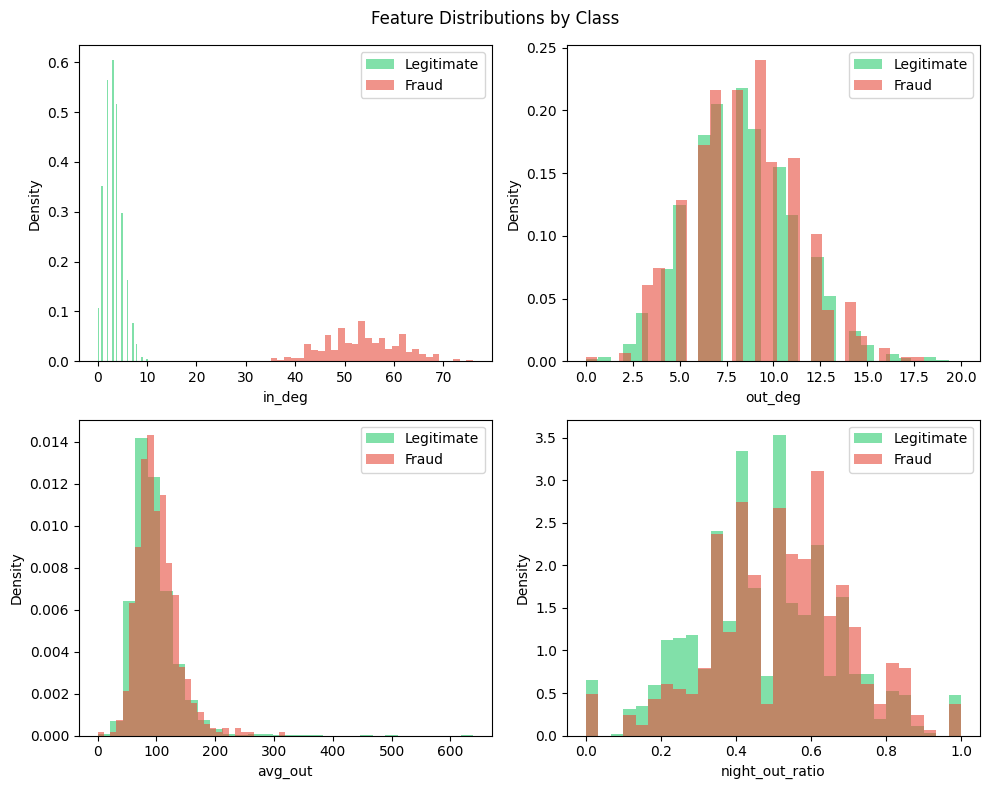

In [9]:
# Compare distributions for key features
key_features = ['in_deg', 'out_deg', 'avg_out', 'night_out_ratio']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    legit = df[df['label'] == 0][feat]
    fraud = df[df['label'] == 1][feat]
    
    ax.hist(legit, bins=30, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
    ax.hist(fraud, bins=30, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions by Class')
plt.tight_layout()
plt.show()

Features show overlapping distributions between fraud and legitimate accounts.

##  Degree Distribution

In [10]:
src, dst = data.edge_index
in_deg = degree(dst, num_nodes=data.num_nodes).numpy()
out_deg = degree(src, num_nodes=data.num_nodes).numpy()

print(f"In-degree: min={in_deg.min():.0f}, max={in_deg.max():.0f}, mean={in_deg.mean():.2f}")
print(f"Out-degree: min={out_deg.min():.0f}, max={out_deg.max():.0f}, mean={out_deg.mean():.2f}")

In-degree: min=0, max=76, mean=8.18
Out-degree: min=0, max=20, mean=8.18


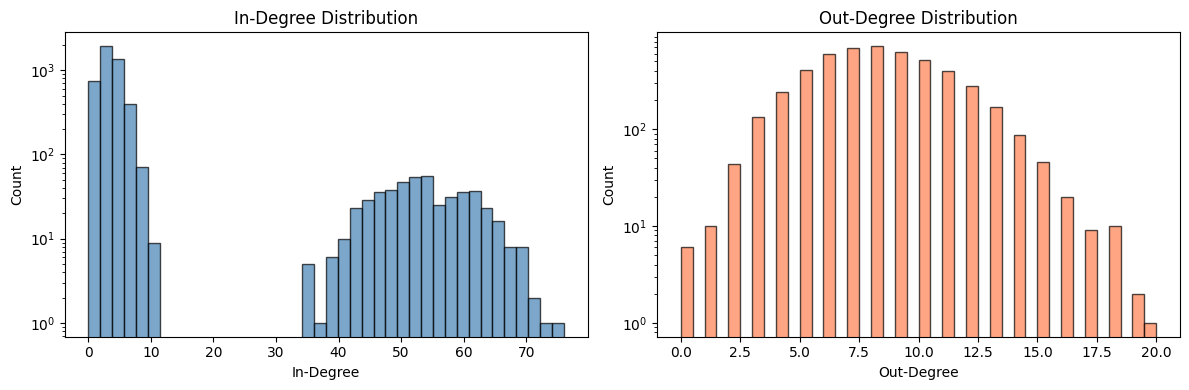

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(in_deg, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('In-Degree Distribution')
axes[0].set_yscale('log')

axes[1].hist(out_deg, bins=40, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Out-Degree Distribution')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Edge Homophily Analysis

In [12]:
# Compute edge homophily: fraction of edges connecting same-label nodes
src_labels = labels[src.numpy()]
dst_labels = labels[dst.numpy()]
same_label = (src_labels == dst_labels).sum()
homophily = same_label / len(src_labels)

print(f"Edge homophily: {homophily:.4f}")

Edge homophily: 0.3131


Low homophily (~0.3) means fraud and legitimate accounts frequently transact with each other. This makes fraud detection harder - you can't simply label an account based on its neighbors' labels.

##  Feature Correlation

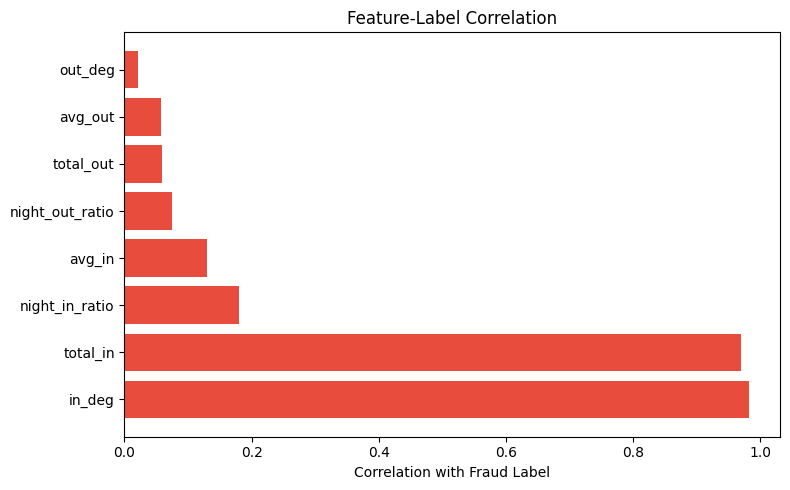

In [13]:
# Correlation with label
corr = df[feature_names[:8] + ['label']].corr()['label'].drop('label')
corr = corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_xlabel('Correlation with Fraud Label')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Feature-Label Correlation')
plt.tight_layout()
plt.show()

Weak correlations between individual features and the fraud label. This confirms that simple threshold-based rules won't work well - we need the GNN to learn complex patterns from graph structure.

## Save Processed Data

In [14]:
from pathlib import Path
import torch

save_path = Path('../data/processed/synthetic_fraud.pt')
save_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(data, save_path)
print(f"Saved to {save_path}")

Saved to ..\data\processed\synthetic_fraud.pt


## Summary

In [15]:
summary = {
    'Metric': ['Nodes', 'Edges', 'Node Features', 'Edge Features', 
               'Fraud Rate', 'Homophily', 'Avg Degree'],
    'Value': [
        data.num_nodes,
        data.num_edges,
        data.x.shape[1],
        data.edge_attr.shape[1],
        f"{labels.mean()*100:.1f}%",
        f"{homophily:.3f}",
        f"{data.num_edges/data.num_nodes:.1f}"
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Nodes,5000
1,Edges,40900
2,Node Features,12
3,Edge Features,5
4,Fraud Rate,9.9%
5,Homophily,0.313
6,Avg Degree,8.2
